# 🌍 Country Data Analysis using REST API

## 📌 Objective
This notebook demonstrates how to:
- Fetch live country data from a public REST API
- Parse JSON responses
- Convert data into a structured format using Pandas
- Perform basic data analysis

## 🔗 API Used
REST Countries API:
https://restcountries.com/v3.1/all

This API provides real-time information about countries including population, region, and area.

## 🔹 Task 1 — Fetch and Validate API Response

In this step:
- We send a GET request to the API
- Check if the response is successful (status code 200)
- Count the number of countries returned
- Handle errors using try-except

In [24]:
import requests

url = "https://restcountries.com/v3.1/all?fields=name,population,region,area"


data = []

try:
    response = requests.get(url, timeout=10)

    print("Status Code:", response.status_code)

    if response.status_code == 200:
        data = response.json()
        print("Total Countries Retrieved:", len(data))
    else:
        print("Failed to fetch data from the API.")

except requests.exceptions.RequestException as e:
    print("Error occurred:", e)

Status Code: 200
Total Countries Retrieved: 250


## 🔹 Task 2 — Extract and Structure Data

In this step:
- We extract key fields from each country:
  - Common Name
  - Population
  - Region
  - Area
- Store the extracted data into a Pandas DataFrame
- Display the first 10 rows## 🔹 Task 2 — Extract and Structure Data

In this step:
- We extract key fields from each country:
  - common_name → Country name
  - population → Total population
  - region → Region/continent
  - area → Total land area

- Use `.get()` method to safely access values
- Store results in a list of dictionaries
- Convert into a Pandas DataFrame
- Display first 10 rows

In [25]:
# Task 2: Extract required fields and create DataFrame
import pandas as pd

# Safety check
if not data:
    raise ValueError("⚠️ Run Task 1 successfully before Task 2")


countries_list = []

for country in data:
    countries_list.append({
        "common_name": country.get("name", {}).get("common"),
        "population": country.get("population"),
        "region": country.get("region"),
        "area": country.get("area")
    })

df = pd.DataFrame(countries_list)

df.head(10)

,common_name,population,region,area
0,Zimbabwe,17073087,Africa,390757.0
1,Kiribati,120740,Oceania,811.0
2,Ghana,33742380,Africa,238533.0
3,North Korea,25950000,Asia,120538.0
4,Spain,49315949,Europe,505992.0
5,Jordan,11734000,Asia,89342.0
6,San Marino,34132,Europe,61.0
7,Ivory Coast,31719275,Africa,322463.0
8,Brazil,213421037,Americas,8515767.0
9,Colombia,53057212,Americas,1141748.0


## 🔹 Task 3 — Data Analysis

In this step:
- We determine which region has the highest total population
  using groupby and sum
- We identify the country with the largest area
  using idxmax()

In [31]:
# Region with highest population
region_population=df.groupby("region")["population"].sum()
highest_region=region_population.idxmax()

# Country with largest area
largest_country= df.loc[df["area"].idxmax(),"common_name"]

print("Region with Highest Total Population:" , highest_region)
print("Country wit Largest Area :" ,largest_country)

Region with Highest Total Population: Asia
Country wit Largest Area : Russia


## ✅ Conclusion

In this notebook:
- Data was successfully fetched from a REST API
- JSON data was structured into a DataFrame
- Key insights were derived using basic analysis

### 📊 Key Findings:
- Region with highest population: Asia
- Largest country by area: Russia

This demonstrates how APIs can be used for real-world data analysis tasks.

## 📊 Data Visualization — Population by Region

In this step:
- We visualize total population by region
- This helps us clearly compare which region has the highest population
- A bar chart is used for better understanding of distribution

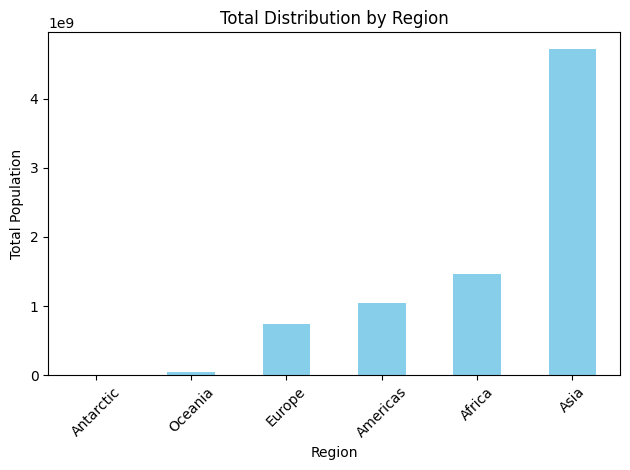

In [37]:
from matplotlib import colors
from numpy import column_stack
from matplotlib.colors import Colormap
import matplotlib.pyplot as plt

# Group population by region
region_population =df.groupby("region")["population"].sum().sort_values(ascending=True)

# Plot bar chart
plt.figure()
region_population.plot(kind='bar',color='skyblue')

# Labels and titles :
plt.xlabel("Region")
plt.ylabel("Total Population")
plt.title("Total Distribution by Region")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 📈 Insight

From the chart, we can clearly observe that:
- Asia has the highest total population
- Other regions like Africa and Europe follow
- Regions like Oceania have comparatively lower population

Visualization makes it easier to understand patterns compared to raw numbers.